In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [9]:
df = pd.read_csv("twitter_training.csv", header=None)

df.columns = [
    "Tweet_ID",
    "Entity",
    "Sentiment",
    "Tweet"
]

df.head()

,Tweet_ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [10]:
print(df.shape)

(74682, 4)


In [11]:
df.isnull().sum()

Tweet_ID       0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

In [12]:
df["Sentiment"].value_counts()

Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

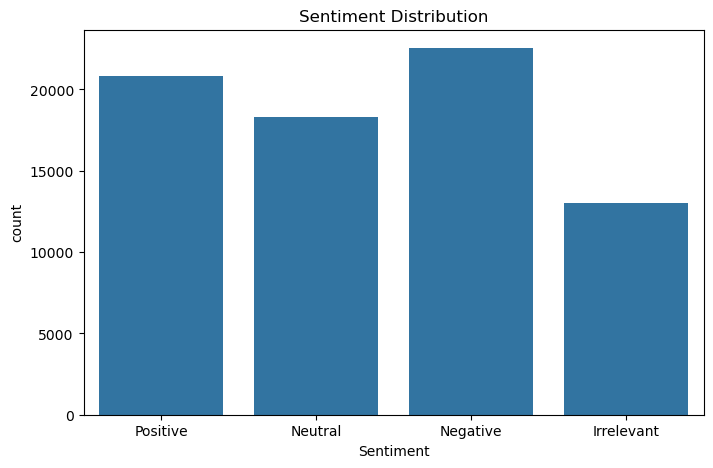

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    x="Sentiment",
    data=df
)

plt.title("Sentiment Distribution")
plt.show()

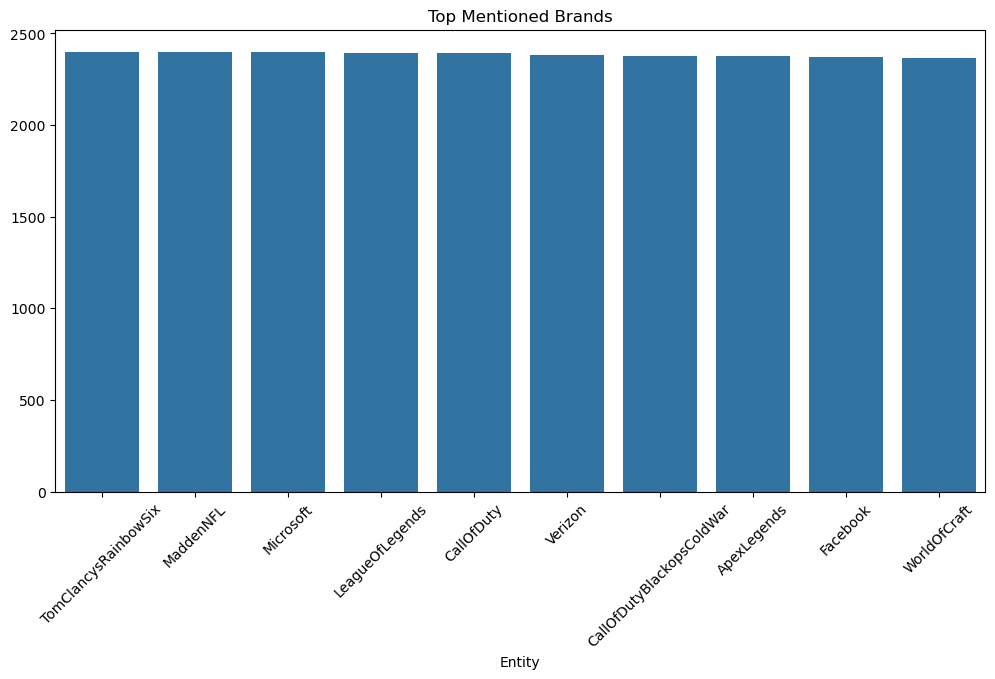

In [14]:
top_entities = df["Entity"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_entities.index,
    y=top_entities.values
)

plt.xticks(rotation=45)
plt.title("Top Mentioned Brands")
plt.show()

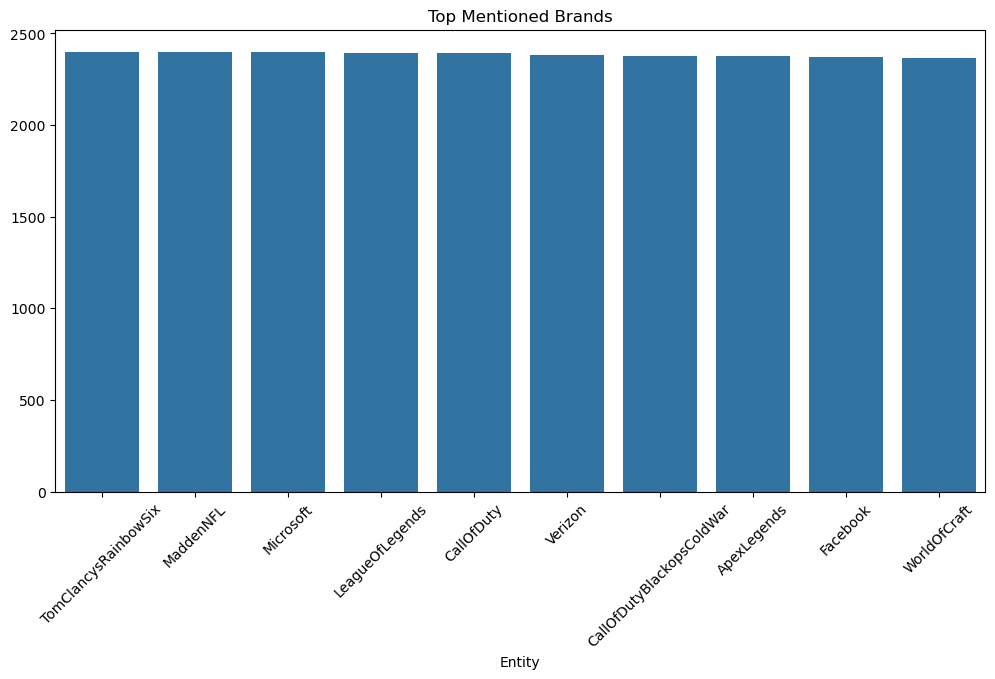

In [15]:
top_entities = df["Entity"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_entities.index,
    y=top_entities.values
)

plt.xticks(rotation=45)
plt.title("Top Mentioned Brands")
plt.show()

In [16]:
brand_sentiment = pd.crosstab(
    df["Entity"],
    df["Sentiment"]
)

brand_sentiment.head()

Sentiment,Irrelevant,Negative,Neutral,Positive
Entity,,,,
Amazon,192,576,1236,312
ApexLegends,192,600,942,642
AssassinsCreed,264,378,156,1446
Battlefield,918,474,360,594
Borderlands,240,426,600,1020


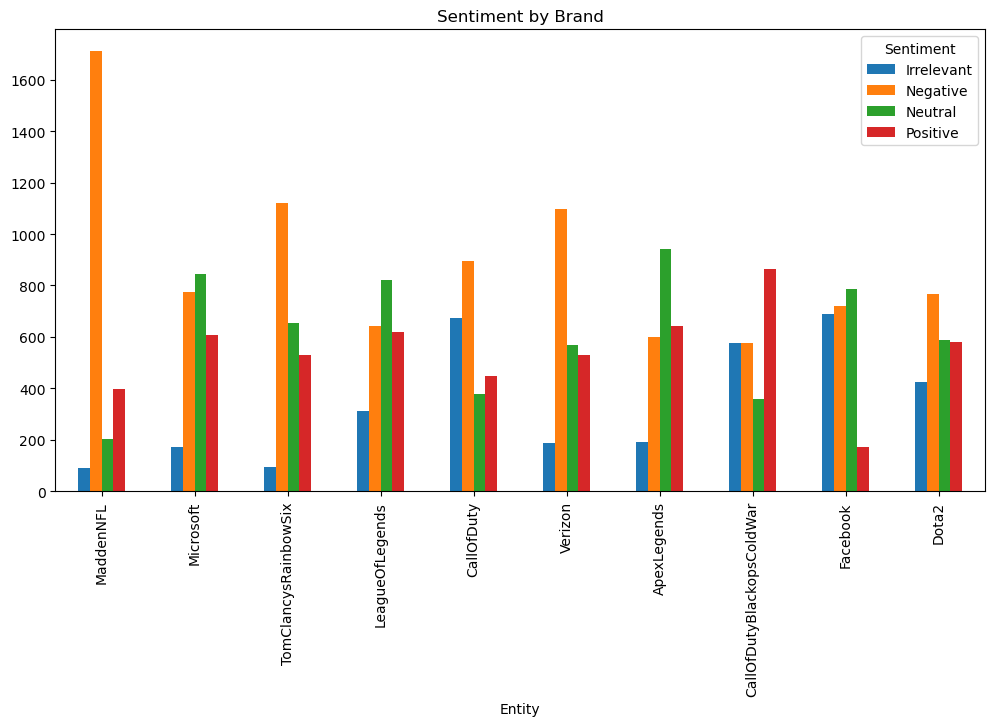

In [34]:

brand_sentiment.loc[
    brand_sentiment.sum(axis=1)
    .sort_values(ascending=False)
    .head(10)
    .index
].plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Sentiment by Brand")
plt.show()

In [35]:
import nltk
nltk.download("punkt")
nltk.download("stopwords")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Sujana\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sujana\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [37]:
stop_words = set(stopwords.words("english"))

In [40]:
def clean_text(text):

    text = str(text).lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = word_tokenize(text)

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [42]:
df["clean_text"] = df["Tweet"].apply(clean_text)

In [43]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X = tfidf.fit_transform(
    df["clean_text"]
)

y = df["Sentiment"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [ ]:
print( accuracy_score(y_test,pred_lr))

In [ ]:
nb = MultinomialNB()

nb.fit(
    X_train,
    y_train
)

pred_nb = nb.predict(X_test)

print(
    accuracy_score(
        y_test,
        pred_nb
    )
)

In [ ]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

print(accuracy_score(y_test,pred_rf))

In [ ]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest"
    ],
    "Accuracy":[
        accuracy_score(y_test,pred_lr),
        accuracy_score(y_test,pred_nb),
        accuracy_score(y_test,pred_rf)
    ]
})

print(results)

In [ ]:
cm = confusion_matrix(
    y_test,
    pred_rf
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.title("Confusion Matrix")
plt.show()

In [ ]:
from wordcloud import WordCloud

In [ ]:
positive_text = " ".join(
    df[df["Sentiment"]=="Positive"]
    ["clean_text"]
)

In [ ]:
wc = WordCloud(
    width=800,
    height=400
).generate(
    positive_text
)

plt.imshow(wc)
plt.axis("off")
plt.show()